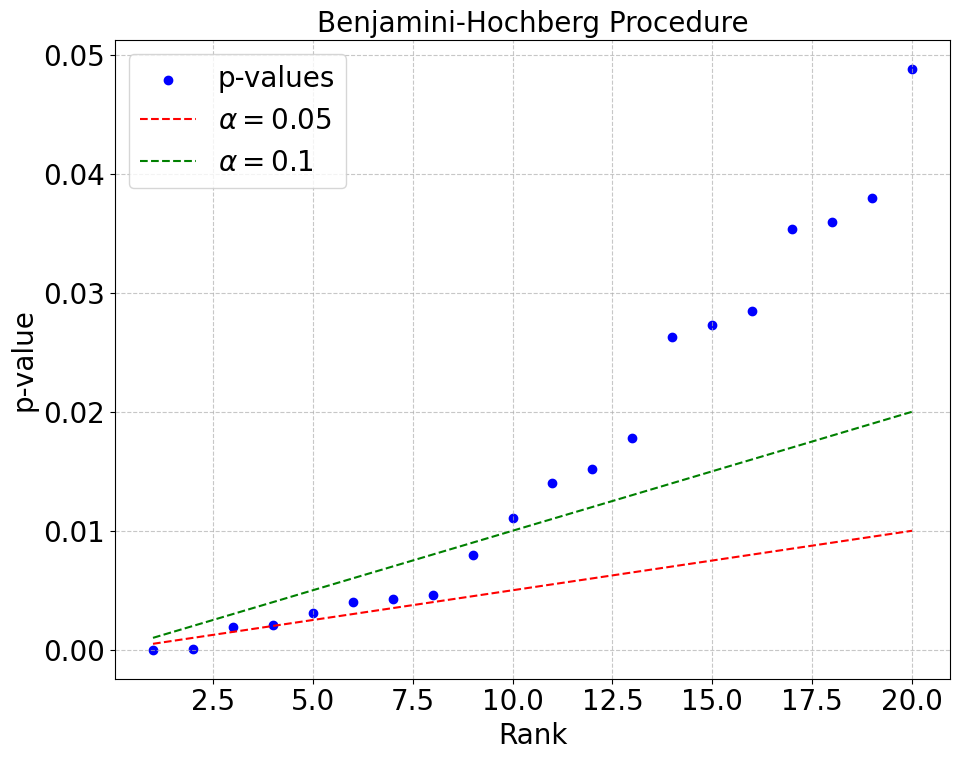

In [117]:
import os
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(103)  # For reproducibility
# Set all font sizes to 18
fs = 20
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs
})

# Simulate p-values from a uniform distribution (for nulls) and a beta distribution (for alternatives)
n_hypotheses = 100
p_values = np.sort(
    np.concatenate([
        np.random.uniform(0, 1, size=70),
        np.random.beta(0.5,5, size=30)
    ])
)

# Plot the first 20 p-values
plt.figure(figsize=(10, 8))
plt.scatter(range(1, 21), p_values[:20], color="blue", label="p-values")

# Plot the BH threshold lines
alpha_values = [0.05, 0.1]
colors = ["red", "green"]
labels = [r"$\alpha = 0.05$", r"$\alpha = 0.1$"]

for alpha, color, label in zip(alpha_values, colors, labels):
    bh_line = alpha * np.arange(1, 21) / n_hypotheses
    plt.plot(range(1, 21), bh_line, "--", color=color, label=label)

plt.xlabel("Rank")
plt.ylabel("p-value")
plt.title("Benjamini-Hochberg Procedure")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Save figure
plt.savefig("adaptive_bh_example.pdf", bbox_inches="tight")
plt.savefig("adaptive_bh_example.png", dpi=300, bbox_inches="tight")

plt.show()